**Imports**

In [76]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, random_split

**Configuration**

In [77]:
TRAIN_CSV = "../data/kaggle/fashion-mnist_train.csv"
TEST_CSV = "../data/kaggle/fashion-mnist_test.csv"

BATCH_SIZE = 64
LEARNING_RATE = 0.001
NUM_EPOCHS = 25
VALID_RATIO = 0.2 # 20% of the training dataset will be used as validation data
DROPOUT_RATE = 0.5
RANDOM_SEED = 42

CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


**Check files**

In [78]:
if not os.path.exists(TRAIN_CSV):
    raise FileNotFoundError(f"Training file not found: {TRAIN_CSV}")

if not os.path.exists(TEST_CSV):
    raise FileNotFoundError(f"Test file not found: {TEST_CSV}")

print("Both files found.")

Both files found.


**Create custom dataset**

In [79]:
class FashionMNISTCSVDataset(Dataset):
    def __init__(self, csv_file):
        df = pd.read_csv(csv_file)

        self.labels = df.iloc[:, 0].to_numpy(dtype=np.int64)
        self.images = df.iloc[:, 1:].to_numpy(dtype=np.float32) / 255.0  # / 255 part nomalizes pixel values, become [0,1]
        self.images = self.images.reshape(-1, 1, 28, 28) # (number_of_images, channels, height, width)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx): # get the sample at position idx
        image = torch.from_numpy(self.images[idx])
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return image, label

**Load datasets**

In [80]:
full_train_dataset = FashionMNISTCSVDataset(TRAIN_CSV)
test_dataset = FashionMNISTCSVDataset(TEST_CSV)

print("Full train dataset size:", len(full_train_dataset))
print("Test dataset size:", len(test_dataset))

Full train dataset size: 60000
Test dataset size: 10000


**Split into train and validation**

In [81]:
train_size = int((1 - VALID_RATIO) * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(RANDOM_SEED)
)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))

Train size: 48000
Validation size: 12000


**Create DataLoaders**

In [82]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

**Inspect one sample**

In [83]:
image, label = full_train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label.item())
print("Class name:", CLASS_NAMES[label.item()])

Image shape: torch.Size([1, 28, 28])
Label: 2
Class name: Pullover


**Show one image**

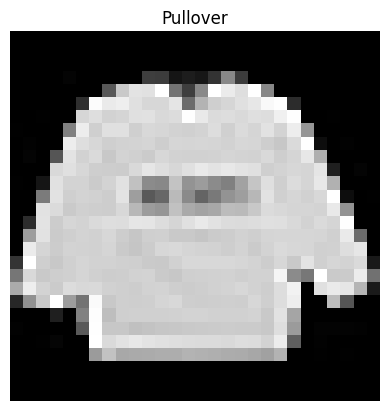

In [84]:
plt.imshow(image.squeeze().numpy(), cmap="gray")
plt.title(CLASS_NAMES[label.item()])
plt.axis("off")
plt.show()

**Define the CNN model**

In [85]:
class FashionCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1), 
            nn.ReLU(), # max(0, x), non-linearity
            nn.MaxPool2d(2, 2), 
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2) 
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(DROPOUT_RATE), # replace by 0
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

**Initialize model, loss, optimizer**

In [86]:
model = FashionCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)

FashionCNN(
  (features): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6272, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


**Training function**

In [87]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader: # images: [batch_size, 1, 28, 28], labels: [batch_size]
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images) # [batch_size, 10]
        loss = criterion(outputs, labels) # computes loss 
        loss.backward() # calculates graadients
        optimizer.step() # updates the model parameters based on the calculated gradients

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1) # predicted class is the index of the largest value, [batch_size]
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

**Evaluation function**

In [88]:
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad(): # tells PyTorch not to calculate gradients, which saves memory and computations during evaluation
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy()) # This saves all predictions and actual labels across all batches
            all_labels.extend(labels.cpu().numpy())

    return running_loss / total, correct / total, np.array(all_preds), np.array(all_labels)

**Train the model**

In [89]:
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

best_val_acc = 0.0
best_val_loss = float("inf")

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss_epoch = epoch + 1
        best_val_loss = val_loss

    if val_acc > best_val_acc:
        best_val_acc_epoch = epoch + 1
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_fashion_cnn.pth") # saves the best model parameters to a file

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print("-" * 50)

print(f"Best Validation Loss: {best_val_loss:.4f} at epoch {best_val_loss_epoch}")
print(f"Best Validation Accuracy: {best_val_acc:.4f} at epoch {best_val_acc_epoch}")

/Users/jiacheng/Documents/NUS_Course/CS3244/group_project/cnn_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch [1/25]
Train Loss: 0.5672 | Train Acc: 0.7907
Val   Loss: 0.3380 | Val   Acc: 0.8745
--------------------------------------------------
Epoch [2/25]
Train Loss: 0.3673 | Train Acc: 0.8695
Val   Loss: 0.2961 | Val   Acc: 0.8914
--------------------------------------------------
Epoch [3/25]
Train Loss: 0.3129 | Train Acc: 0.8866
Val   Loss: 0.2751 | Val   Acc: 0.8986
--------------------------------------------------
Epoch [4/25]
Train Loss: 0.2762 | Train Acc: 0.9012
Val   Loss: 0.2400 | Val   Acc: 0.9118
--------------------------------------------------
Epoch [5/25]
Train Loss: 0.2535 | Train Acc: 0.9086
Val   Loss: 0.2340 | Val   Acc: 0.9134
--------------------------------------------------
Epoch [6/25]
Train Loss: 0.2317 | Train Acc: 0.9159
Val   Loss: 0.2333 | Val   Acc: 0.9163
--------------------------------------------------
Epoch [7/25]
Train Loss: 0.2134 | Train Acc: 0.9228
Val   Loss: 0.2214 | Val   Acc: 0.9203
--------------------------------------------------
Epoch 

**Load best model and evaluate on test set**

In [90]:
model.load_state_dict(torch.load("best_fashion_cnn.pth", map_location=device))

test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion, device)

print("Final Test Results")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Final Test Results
Test Loss: 0.2572
Test Accuracy: 0.9325


In [91]:
results_df = pd.DataFrame({
    "epoch": range(1, len(train_losses) + 1),
    "train_loss": train_losses,
    "train_accuracy": train_accuracies,
    "val_loss": val_losses,
    "val_accuracy": val_accuracies
})

results_df.to_csv("../outputs/cnn/standard_training_results_Conv64_dropout_0.5.csv", index=False)

**Plot loss curves**

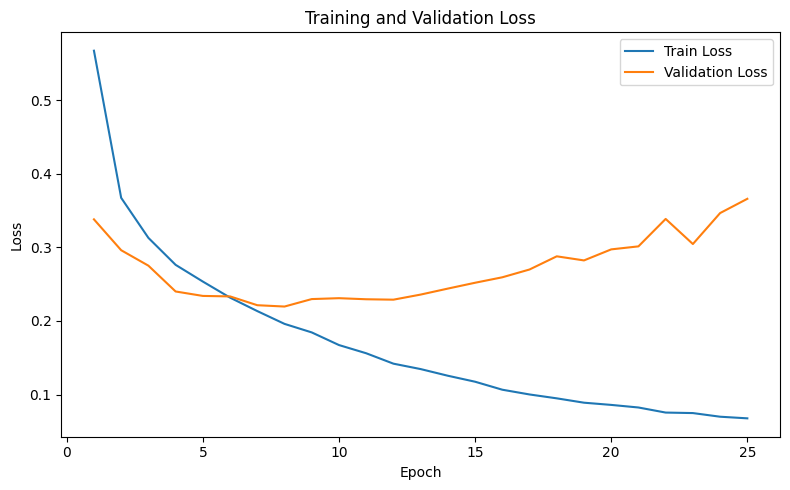

In [92]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, label="Train Loss")
plt.plot(range(1, NUM_EPOCHS + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

**Plot accuracy curves**

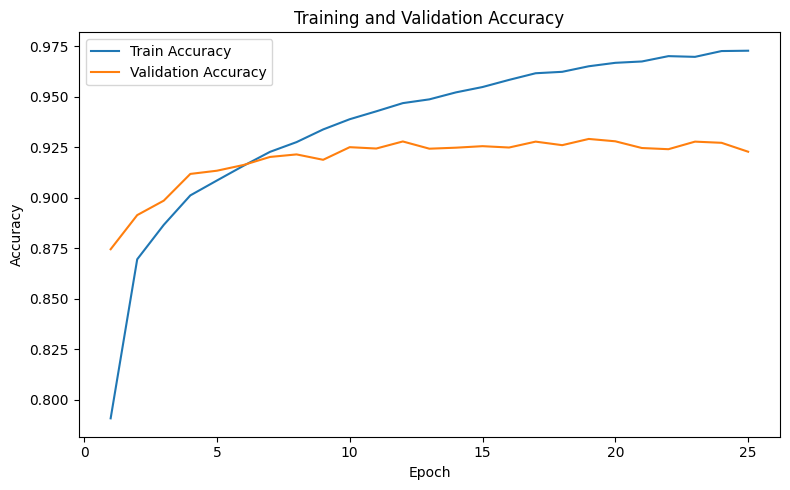

In [93]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, NUM_EPOCHS + 1), train_accuracies, label="Train Accuracy")
plt.plot(range(1, NUM_EPOCHS + 1), val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

**Show sample predictions**

In [94]:
def show_predictions(model, dataset, class_names, device, num_images=10):
    model.eval()
    indices = np.random.choice(len(dataset), num_images, replace=False)

    plt.figure(figsize=(12, 6))
    for i, idx in enumerate(indices):
        image, label = dataset[idx]
        image_input = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(image_input)
            pred = output.argmax(dim=1).item()

        plt.subplot(2, 5, i + 1)
        plt.imshow(image.squeeze().cpu().numpy(), cmap="gray")
        plt.title(f"P: {class_names[pred]}\nT: {class_names[label.item()]}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

**Run prediction display**

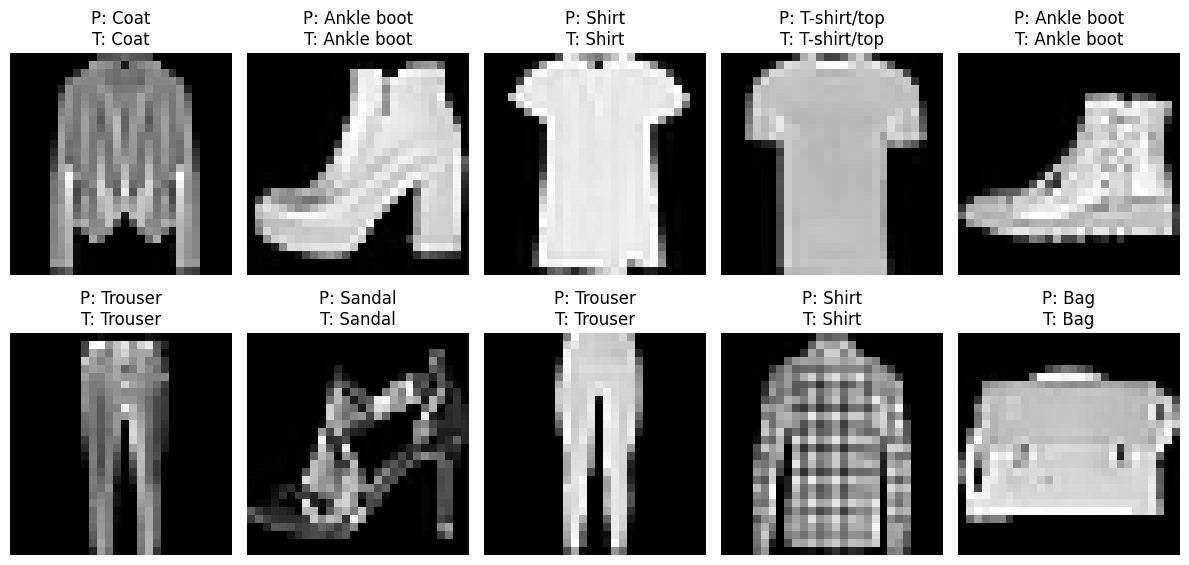

In [95]:
show_predictions(model, test_dataset, CLASS_NAMES, device, num_images=10)